# Debiasing Facial Detection Systems

In [1]:
import os, sys
import yaml
from box import Box
import random
import IPython
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
from pathlib import Path
from PIL import Image

#cfg = Box(yaml.safe_load(open('../config/config.yaml')), default_box=True)
#param = Box(yaml.safe_load(open('../config/dbvae.yaml')), default_box=True)

In [2]:
sys.path

['/Users/xqyn/miniconda3/envs/ai/lib/python311.zip',
 '/Users/xqyn/miniconda3/envs/ai/lib/python3.11',
 '/Users/xqyn/miniconda3/envs/ai/lib/python3.11/lib-dynload',
 '',
 '/Users/xqyn/miniconda3/envs/ai/lib/python3.11/site-packages',
 '/Users/xqyn/Documents/src/dev/irelium/src']

In [3]:
# Import torch
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F
# import torch.backends.cudnn as cudnn
import mitdeeplearning as mdl

/Users/xqyn/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.accelerator.current_accelerator()

print(torch.__version__)
# print("CUDA available :", torch.cuda.is_available())
# print("Device count   :", torch.cuda.device_count())
# print("GPU name       :", torch.cuda.get_device_name(0))
# print("VRAM total     :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")

2.11.0


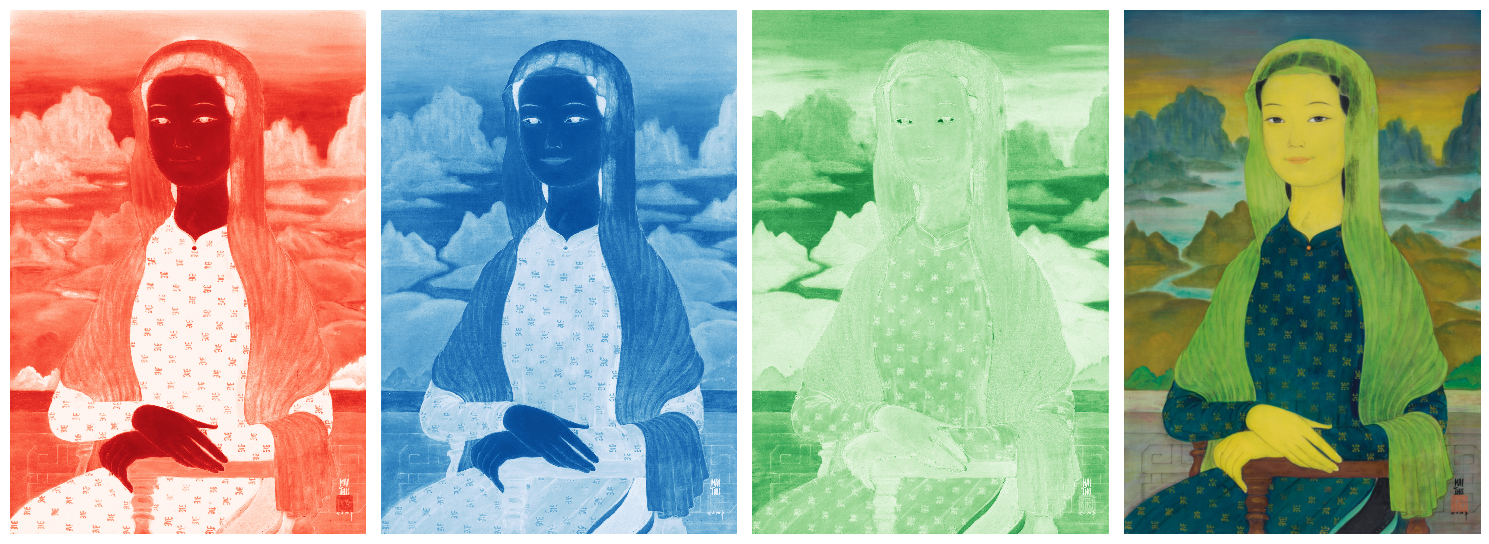

In [6]:
img_path = "../img/mona_lisa_maitrungthu.jpg"
img = [np.array(Image.open(img_path))]  # list so img[0] works

ind = 0  # use 0 since there's only one image

img1  = img[ind].T[0]
img2 = img[ind].T[1]
img3 = img[ind].T[2]


fig, axs = plt.subplots(1, 4, figsize=(15, 7))
for ax, (img_channel, cmap) in zip(axs.flat, [
    (img1,  'Reds'),
    (img2, 'Blues'),
    (img3, 'Greens'),
]):
    sns.heatmap(img_channel.T, cmap=cmap, alpha=1, ax=ax,
                linewidths=0,
                xticklabels=False, yticklabels=False, cbar=False,
                cbar_kws={'orientation': 'horizontal', 'location': 'bottom', 'pad': 0.05})
    ax.set_aspect('equal')
    sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)

axs[3].imshow(img[ind])
axs[3].set_aspect('equal')
axs[3].set_axis_off()

plt.tight_layout()
plt.show()

In [9]:
# --- loading data
CACHE_DIR = Path('/Users/xqyn/Documents/learning/ai/mit6.S191_deeplearning/lab2/data')
#CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Get the training data: both images from CelebA and ImageNet
path_to_training_data = CACHE_DIR.joinpath("train_face.h5")

# # Create a simple check to avoid re-downloading
# if path_to_training_data.is_file():
#     print(f"Using cached training data from {path_to_training_data}")
# else:
#     print(f"Downloading training data to {path_to_training_data}")
#     url = "https://www.dropbox.com/s/hlz8atheyozp1yx/train_face.h5?dl=1"
#     torch.hub.download_url_to_file(url, path_to_training_data)

# Instantiate a TrainingDatasetLoader using the downloaded dataset
channels_last = False
loader = mdl.lab2.TrainingDatasetLoader(
    path_to_training_data, channels_last=channels_last
)

Opening /Users/xqyn/Documents/learning/ai/mit6.S191_deeplearning/lab2/data/train_face.h5
Loading data into memory...


In [10]:
(images, labels) = loader.get_batch(100)
B, C, H, W = images.shape
print(f'{B}-{C}-{H}-{W}')

100-3-64-64


In [4]:
B, C, H, W = 100, 3, 64, 64

## Trainining data on model baseline CNN model

In [6]:
#sys.path.insert(0, str((Path.cwd() / '../').resolve()))
from architecture.cnn import cnnConvNorm

In [7]:
cnn_baseline = cnnConvNorm(
    n_outputs=1,
    H=H,
    W=W,
    in_channels=3,
    base_filter=12,
    stride=2,
    channel_schedule=[1, 2, 4, 6]
    
)